# SPRINT 11 Visualització de dades

### Nivell 1


#### Exercici 1:
1.1 Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [337]:
# Importar el conector 
#%pip install mysql-connector-python
import mysql.connector

In [338]:
def conexion_mysql():
    """
    Función para conectar pyhton a mysql con credenciales determinadas
    """
    conexion =  mysql.connector.connect(
        host="localhost",
        user="root",
        password="rootroot",
        port=3306,
        database= "ecommerce")

    if conexion.is_connected():
            print("¡Conectado!")
    
    return conexion

In [339]:
# Llamada de la función
conexion = conexion_mysql()

¡Conectado!


In [340]:
import pandas as pd
# Obtiene todas las tablas de la base de datos
instruccion = conexion.cursor()
instruccion.execute("SHOW TABLES") 

# fetchall() Devuelve una lista de tuplas con los nombres de las tablas.
tablas = [tabla[0] for tabla in instruccion.fetchall()] 
# Finalizar el envío de instrucciones de SQL
instruccion.close() 

# Crear una variable que comience por df_(nombre_tabla) con cada una de las tablas.
#  El valor es el resultado de la consulta SQL
for tabla in tablas:
    globals()[f"df_{tabla}"] = pd.read_sql(f"SELECT * FROM {tabla}", conexion) 

print(f"Se han cargado {len(tablas)} tablas:")
print(tablas)


/var/folders/qf/7t2996hn51n32dnx304cpkcm0000gn/T/ipykernel_66948/1869621570.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  globals()[f"df_{tabla}"] = pd.read_sql(f"SELECT * FROM {tabla}", conexion)


Se han cargado 7 tablas:
['card_condition', 'companies', 'credit_cards', 'products', 'transaction_products', 'transactions', 'users']


In [341]:
# Análisis: verificar que los df se han generado correctamente con sus tablas y contenido.
df_card_condition.head(5)
df_products.head(5)
df_companies.head(5)
df_credit_cards.head(5)
df_transaction_products.head(5)
df_transactions.head(5)
df_users.head(5)

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,continent
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,America
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave,America
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.,America
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,America
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.,America


In [342]:
# Instalación de plotly

!pip install plotly

#### Exercici 2:
Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.



In [343]:
# Importar librerias de visualización

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


2.1 Variable numèrica.

Text(0, 0.5, 'Número de productos')

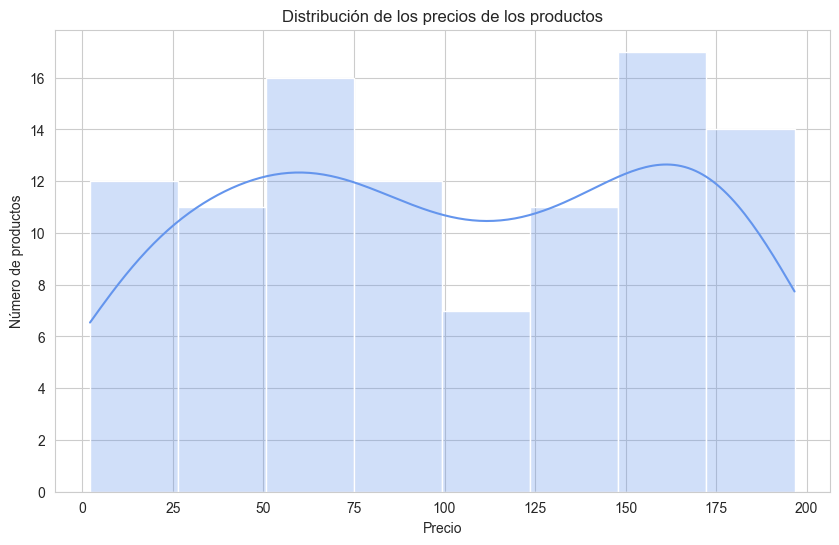

In [410]:

plt.figure(figsize=(10,6))
sns.histplot(data= df_products, x="price", bins="auto", kde=True, alpha = 0.3, color="cornflowerblue", linewidth=1)
plt.title("Distribución de los precios de los productos")
plt.xlabel("Precio")
plt.ylabel("Número de productos")

#### INTERPRETACIÓN 
El histograma muestra que la cantidad de productos se concentra en los rangos de precio entre 50 y 75 dólares y de 150 a 175 dólares. Esto sugiere que podrían existir dos grupos de productos diferentes según su precio (por ejemplo, uno de gama básica y otro de gama alta), en vez de tener los precios repartidos de forma uniforme.

El rango de entre 100 y 125 dólares es el que menos productos tiene. Esto podría significar que esa franja no es está cubierta, bien por una decición estratégica de negocio o porque aún no está explorada.

2.2 Dues variables numèriques.

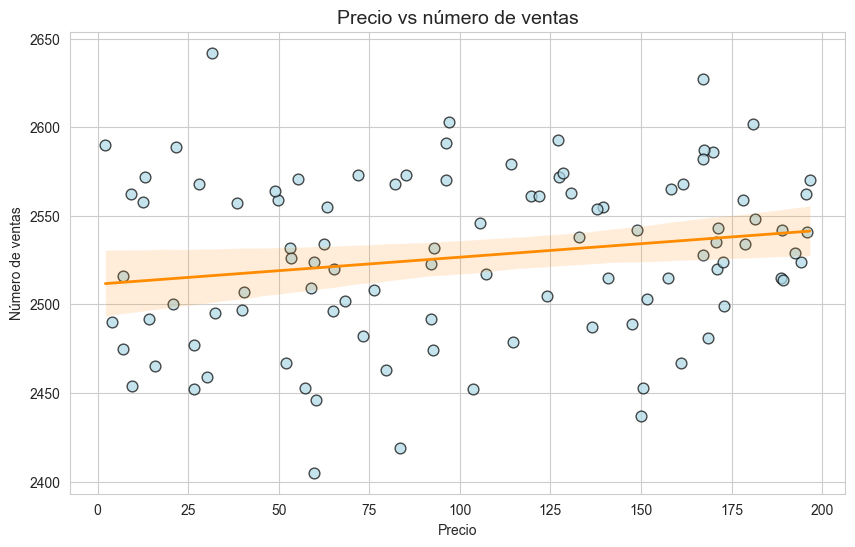

In [421]:

# df con las columnas que necesito de df_products:
produ = df_products[["id", "product_name","price"]]

# Filtrar solo las transacciones no rechazadas
df_trans_pro = df_transaction_products[df_transaction_products["declined"] == 0]

# df = con la agrupación de producto y el recuento de id_transacciones con nombre de col num_ventas
ventas = df_trans_pro.groupby("product_id").agg(num_ventas=("transaction_id","count")).reset_index()

# Merge de los dos DF (Contienen: id, nombre producto, precio, num_ventas)
price_trans = pd.merge(produ, ventas, left_on="id", right_on="product_id", how="left")

# Hacer gráfico:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")        # fondo rejilla
sns.regplot(data=price_trans, x="price", y="num_ventas", 
            scatter_kws={"color":"lightblue",       # color de relleno de los puntos
                        "edgecolor": "black",     # línea que delimita cada punto
                        "alpha": 0.7,             # transparencia
                        "s": 60},                 # tamaño de los puntos
                        line_kws={"color": "darkorange", "linewidth": 2})


plt.title("Precio vs número de ventas", fontsize=14)
plt.xlabel("Precio")
plt.ylabel("Número de ventas")

plt.show()

In [422]:
# Coeficiente de correlación para ver si se relaciona el precio con el número de ventas:
price_trans["price"].corr(price_trans["num_ventas"])


np.float64(0.19309866405490864)

#### INTERPRETACIÓN 
El gráfico muestra que el precio ("price") y el número de productos vendidos ("num_ventas") no tienen una relación clara. Los puntos están muy dispersos entre sí y la línea de regresión apenas muestra inclinación. El cálculo del coeficiente de correlación es de 0.19, lo que indica una correlación muy débil, por lo que el precio tiene poca influencia sobre el número de ventas.

2.3 Una variable categòrica.

In [431]:
# Hacer recuento de los usuarios:
df_country = df_users.groupby("country").agg(num_users=("id","count")).reset_index()

plt.figure(figsize=(10,6))
mapa = px.choropleth(df_country,
              locations="country",
              locationmode="country names",
              color="num_users",            # Intensidades según esta columna
              color_continuous_scale="Greens",
              title="Número de usuarios por país")

# Para cambiar el nombre de la barra degradada
mapa.update_layout(title_x=0.5,coloraxis_colorbar=dict(title="Número de usuarios"))
mapa.show()


/var/folders/qf/7t2996hn51n32dnx304cpkcm0000gn/T/ipykernel_66948/2686843142.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  mapa = px.choropleth(df_country,


<Figure size 1000x600 with 0 Axes>

#### INTERPRETACIÓN
El mapa muestra una distribución bastante uniforme de usuarios por país. Norteamérica concentra un mayor número de usuarios, especialmente Estados Unidos, aunque las diferencias con el resto de países son moderadas.

2.4 Una variable categòrica i una numèrica.


In [439]:
# Merge de transacciones con usuarios
trans_users = pd.merge(df_transactions, df_users,left_on="users_id",right_on="id")

# Importe medio por país
df_country_amount = (trans_users.groupby("country").agg(amount_mean=("amount", "mean")).reset_index())

# Redondear el df a dos decimales
df_country_amount = df_country_amount.round(2)

grafico = px.bar(df_country_amount, x="country",y="amount_mean",text="amount_mean",
                title="Importe medio de las transacciones por país",
                color_discrete_sequence=["lightblue"])

grafico.update_traces(textposition="outside")
grafico.update_yaxes(range=[250,265]) #Para hacer zoom y que se vea el tramo
grafico.update_layout(xaxis_title="País", yaxis_title="Importe medio de las transacciones")

grafico.show()

#### INTERPRETACIÓN
En el siguiente gráfico de barras se observa que el importe medio de las transacciones es muy similar entre los distintos países, oscilando aproximadamente entre los 255 y los 260 dólares por transacción. Para apreciar mejor estas pequeñas diferencias, el eje Y se ha representado con un zoom comprendido entre 250 y 265 dólares. Aun así, las variaciones son reducidas. Estados Unidos presenta el importe medio más elevado, mientras que Francia registra el más bajo.

2.5 Dues variables categòriques.

In [446]:
# Filtrar transacciones rechazadas
trans_declined = df_transactions[df_transactions["declined"] == 1]

# Merge con usuarios
country_declined = pd.merge(trans_declined,df_users,left_on="users_id", right_on="id")

# Recuento por país
country_declined = (country_declined.groupby("country").agg(num_declined=("declined","count")).reset_index()
    .sort_values("num_declined"))

# Calcular la media
media = country_declined["num_declined"].mean()

# Gráfico
fig = px.bar(country_declined,x="num_declined",y="country",
    orientation="h",
    text="num_declined",
    color_discrete_sequence=["coral"],
    title="Número de transacciones rechazadas por país",
    labels={"country": "País",
            "num_declined": "Transacciones rechazadas"})

# Línea de la media
fig.add_vline(x=media,line_dash="dash",line_color="darkblue",
    annotation_text=f"Media: {media:.1f}",  # Para que aparezca el cálculo de la media
    annotation_position="top")

fig.update_layout(title_x=0.5)
fig.update_traces(textposition="outside")

fig.show()

#### INTERPRETACIÓN


El gráfico muestra que Estados Unidos registra el mayor número de transacciones rechazadas (75), mientras que Alemania presenta el menor (9). Sin embargo, este gráfico representa valores absolutos, por lo que no permite concluir qué país tiene una mayor tasa de rechazo. Para ello sería necesario conocer el número total de transacciones realizadas en cada país y calcular el porcentaje de transacciones rechazadas.

2.6 Tres variables combinades.

In [ ]:

# Transacciones aceptadas
trans_acept = df_transactions[df_transactions["declined"] == 0]

# Unir tablas
df_plot = (trans_acept
    .merge(df_users, left_on="users_id", right_on="id")
    .merge(df_transaction_products, left_on="id_x", right_on="transaction_id")
    .merge(df_products, left_on="product_id", right_on="id"))

# Obtener los 3 productos más vendidos
top3 = (df_plot["product_name"] .value_counts().head(3).index)

# Filtrar solo esos productos
df_plot = df_plot[df_plot["product_name"].isin(top3)]

# Contar ventas por país y producto
df_plot = (df_plot.groupby(["country", "product_name"]).size().reset_index(name="sales"))


fig = px.bar(df_plot, x="country", y="sales",
    color="product_name",
    barmode="group", # También se puede usar stack    
    title="Ventas de los 3 productos más populares por país",
    color_discrete_sequence=px.colors.qualitative.Set2)

fig.update_layout(
    title_x=0.5,
    xaxis_title="País",
    yaxis_title="Número de ventas",
    legend_title="Nombre del producto")

fig.show()

#### INTERPRETACIÓN
El gráfico muestra el número de ventas de los tres productos más vendidos en cada país. En general, las ventas de los tres productos son bastante similares dentro de cada país con pequeñas diferencias. Estados Unidos muestra el mayor número de ventas para los tres productos, mientras que Francia, Polonia y Suecia presentan los valores más bajos. Además, el producto The Duel es el más vendido en Estados Unidos y Canadá, mientras que en otros países el producto más vendido varía.

2.7 Crea un Pairplot.

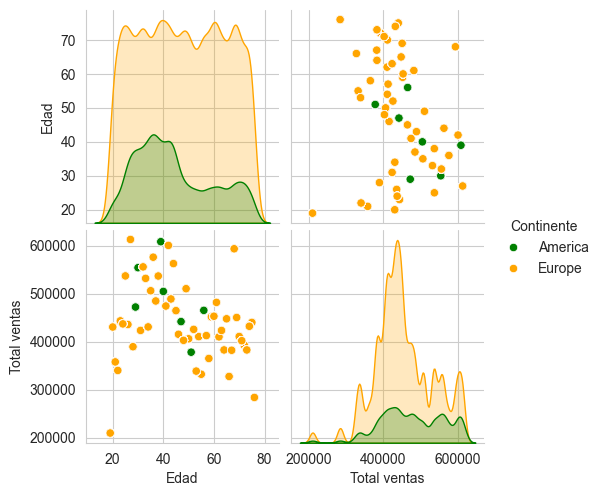

In [ ]:
from datetime import datetime

# Columna de edad en df_users
df_users['age'] = df_users['birth_date'].apply(lambda x:(pd.to_datetime('today') - pd.to_datetime(x)).days // 365)


# Merge con las columnas que necesito definidas
usuario_amount = pd.merge(df_users[["id","age","continent"]], trans_acept[["amount","users_id"]], left_on="id", right_on="users_id", how="inner")

pd.options.display.float_format = '{:,.2f}'.format #(Formato miles en inglés con ,)
edad_amount = usuario_amount.groupby("age").agg(amount_sum = ("amount", "sum")).reset_index() 

age_sum = pd.merge(usuario_amount, edad_amount, on="age", how="inner")
age_sum = age_sum.rename(columns={ "age": "Edad","amount_sum": "Total ventas"})

image= sns.pairplot(age_sum, vars=["Edad", "Total ventas"],
                  hue="continent",
                  diag_kind="kde",
                  palette=["green","orange"])

image._legend.set_title("Continente")
plt.show()

#### INTERPRETACIÓN
El pairplot muestra la relación entre la edad y el total de ventas, diferenciando los usuarios por continente. Se observa que los valores máximos se concentran entre los 30-50 años. Además, los usuarios de América concentran los mayores importes de ventas, especialmente a partir de los 400.000, mientras que Europa presenta valores más moderados. No obstante, este gráfico representa el total de ventas por edad, por lo que no permite concluir el comportamiento de los usuarios de forma individual.Asimismo, este resultado puede estar influido por el número de usuarios que hay en cada edad, por lo que no permite afirmar que los usuarios de esas edades gasten más de forma individual.

### NIVELL 2

#### Exercici 1:
Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

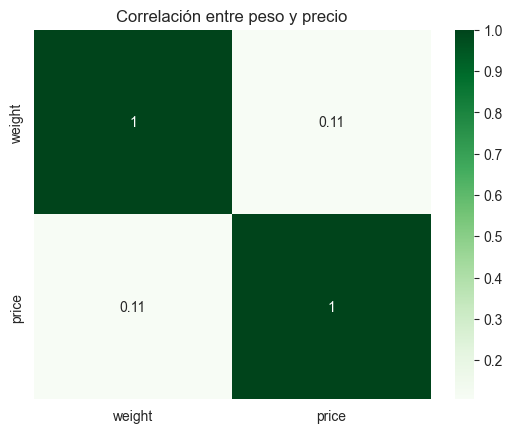

In [492]:
import seaborn as sns
import matplotlib.pyplot as plt

correlacion = df_products[["weight", "price"]].corr()

sns.heatmap(correlacion, annot=True, cmap="Greens")
plt.title("Correlación entre peso y precio")
plt.show()

In [493]:
df_products["price"].corr(df_products["weight"])

np.float64(0.10543096698640232)

#### INTERPRETACIÓN

El siguiente gráfico muestra que el peso ("weight") y el precio("price") no tienen una correlación definida. Además el cálculo del coeficiente de correlación es de 0.10, lo que indica que es una correlación muy débil, por lo que el peso tiene muy poca influencia en el precio que se le asigna al producto.

#### Exercici 2:
Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades


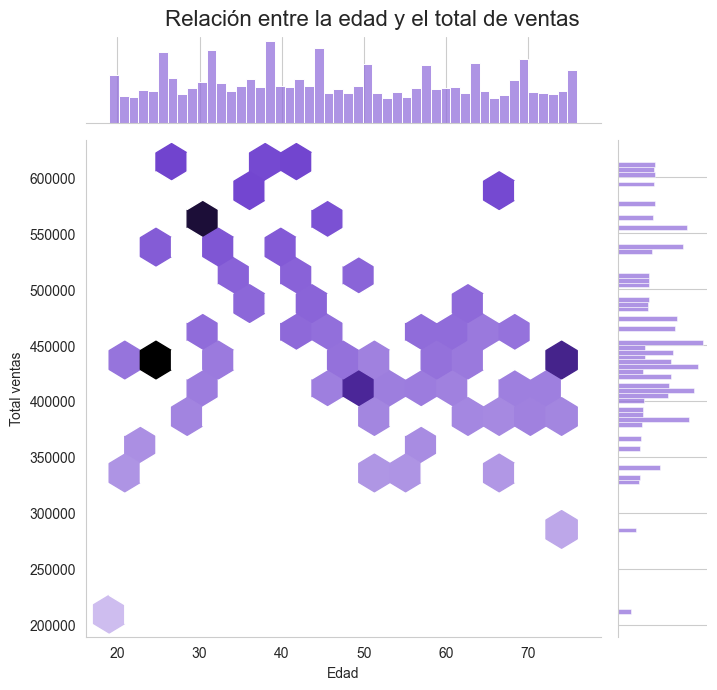

In [ ]:
joint = sns.jointplot(data=age_sum, x="Edad", y="Total ventas",kind="hex",
                      marginal_kws=dict(fill=True),   # KDE relleno en los márgenes
                      color="mediumpurple",
                      height=7,
                      joint_kws={"gridsize": 15})

joint.ax_joint.grid(False) # Quitar grid central
plt.suptitle("Relación entre la edad y el total de ventas",fontsize=16)
plt.subplots_adjust(top=0.94)

plt.show()

#### INTERPRETACIÓN
Se observa en este gráfico que la mayor parte de los datos se concentra en un total de ventas comprendido aproximadamente entre los 350.000 y los 500.000. No se aprecia una relación lineal clara entre la edad y el total de ventas, ya que los valores aparecen dispersos a lo largo de casi todo el rango de edades. Los importes más elevados se observan principalmente entre los 30 y los 45 años, aunque existen algunos casos aislados en edades superiores.No obstante, al representar el total de ventas por edad, estos resultados pueden estar condicionados por el número de usuarios que existe en cada grupo de edad, por lo que no permiten extraer conclusiones sobre el comportamiento individual de los usuarios.